# Phase 00–02 EDA — review of the downloaded data

Purpose: **verify the raw downloads before any science is computed from them.**
Each section says where the data comes from, shows the variables as downloaded,
maps the domain with political boundaries, and runs preliminary sanity checks.

| source | what | variables | cadence | extent | windows on disk |
|---|---|---|---|---|---|
| ERA5 via Google's **ARCO** mirror (public Zarr, anonymous) | reanalysis — best estimate of the real atmosphere | `u100`, `v100`, `ws100`, `sp` hourly; `z500` 6-hourly | hourly | Euro-Atlantic box 30–75°N, 40°W–40°E, 0.25° | Jan 2023; Nov–Dec 2024 |
| **SMARD** (Bundesnetzagentur API) | observed German feed-in + installed capacity | wind onshore, wind offshore, solar — MW | hourly | 4 TSO zones (50Hertz, TenneT, Amprion, TransnetBW) | Jan 2023; Nov–Dec 2024 |

Not yet downloaded: **EERIE IFS-FESOM2** (the coupled climate model — gated to Phase 06).
The two windows were chosen deliberately: Jan 2023 as a pipeline smoke test, Nov–Dec 2024
because it contains the well-documented German dark-lull events the project studies.


In [1]:
# Setup: load the cached ERA5 Zarr windows + SMARD client, and define the shared map
# helper (PlateCarree projection + coastlines + country borders + lat/lon gridlines).
import glob
import os
import pathlib
from datetime import datetime

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import xarray as xr
import yaml

from eurogrid.data.smard import SmardClient, capacity_factor
from eurogrid.models.transfer import FLEET_BOXES

ROOT = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config/settings.yaml").exists()
)
os.chdir(ROOT)
cfg = yaml.safe_load(open(ROOT / "config/settings.yaml"))

PC = ccrs.PlateCarree()  # lat/lon projection used for every map
WINDOWS = {"2023-01": ("2023-01-01", "2023-02-01"), "2024-11..12": ("2024-11-01", "2025-01-01")}
era5 = {
    w: xr.open_zarr(
        glob.glob(
            f"data/era5/era5_{datetime.fromisoformat(s):%Y%m%dT%H}"
            f"_{datetime.fromisoformat(e):%Y%m%dT%H}_*.zarr"
        )[0],
        consolidated=True,
    )
    for w, (s, e) in WINDOWS.items()
}


def map_ax(ax, title, borders=True):
    """Common map decoration: extent, coastlines, borders, lat/lon labels."""
    ax.coastlines(resolution="50m", lw=0.7)
    if borders:
        ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.4, alpha=0.7)
    gl = ax.gridlines(draw_labels=True, lw=0, alpha=0)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {"size": 7}
    ax.set_extent([-40, 40, 30, 75])
    ax.set_title(title, fontsize=10)
    return ax


era5.keys()

dict_keys(['2023-01', '2024-11..12'])

## 1. ERA5 — where it comes from and what was downloaded

ECMWF's hourly reanalysis at 0.25°, read from Google's ARCO mirror
(`gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3`).
The loader crops to the domain, wraps longitude to [−180°, 180°), keeps latitude
descending, and writes a local Zarr — the files in `data/era5/`.

**Variables and why each one exists in this project:**
- `u100`, `v100` — eastward/northward wind at 100 m (turbine hub height).
- `ws100` — 100 m wind speed = hypot(u100, v100); the wind resource itself.
- `sp` — surface pressure; needed later to flag where a climate-model pressure level sits below ground.
- `z500` — geopotential height of the 500 hPa surface, on a separate 6-hourly `time_z500` axis
  (each hourly field costs a 37-level global chunk; the blocking index is a daily diagnostic, so 6 h suffices).


In [2]:
# Inventory: every variable in the cached ERA5 datasets — dims, shape, units, time range.
rows = []
for w, ds in era5.items():
    for v in ds.data_vars:
        da = ds[v]
        rows.append(
            {
                "window": w,
                "variable": v,
                "dims": str(da.dims),
                "shape": tuple(da.shape),
                "units": da.attrs.get("units"),
                "first": str(da[da.dims[0]].values[0])[:19],
                "last": str(da[da.dims[0]].values[-1])[:19],
            }
        )
pl.DataFrame(rows)

window,variable,dims,shape,units,first,last
str,str,str,list[i64],str,str,str
"""2023-01""","""sp""","""('time', 'lat', 'lon')""","[744, 181, 321]","""Pa""","""2023-01-01T00:00:00""","""2023-01-31T23:00:00"""
"""2023-01""","""u100""","""('time', 'lat', 'lon')""","[744, 181, 321]","""m s-1""","""2023-01-01T00:00:00""","""2023-01-31T23:00:00"""
"""2023-01""","""v100""","""('time', 'lat', 'lon')""","[744, 181, 321]","""m s-1""","""2023-01-01T00:00:00""","""2023-01-31T23:00:00"""
"""2023-01""","""ws100""","""('time', 'lat', 'lon')""","[744, 181, 321]","""m s-1""","""2023-01-01T00:00:00""","""2023-01-31T23:00:00"""
"""2023-01""","""z500""","""('time_z500', 'lat', 'lon')""","[124, 181, 321]","""m""","""2023-01-01T00:00:00""","""2023-01-31T18:00:00"""
"""2024-11..12""","""sp""","""('time', 'lat', 'lon')""","[1464, 181, 321]","""Pa""","""2024-11-01T00:00:00""","""2024-12-31T23:00:00"""
"""2024-11..12""","""u100""","""('time', 'lat', 'lon')""","[1464, 181, 321]","""m s-1""","""2024-11-01T00:00:00""","""2024-12-31T23:00:00"""
"""2024-11..12""","""v100""","""('time', 'lat', 'lon')""","[1464, 181, 321]","""m s-1""","""2024-11-01T00:00:00""","""2024-12-31T23:00:00"""
"""2024-11..12""","""ws100""","""('time', 'lat', 'lon')""","[1464, 181, 321]","""m s-1""","""2024-11-01T00:00:00""","""2024-12-31T23:00:00"""


### 1.1 The domain

Shaded: January-2023 mean 100 m wind speed. Red rectangle: the static **onshore fleet-proxy box**
(Germany). Blue: the **offshore North-Sea-Bight proxy box** used by the Phase 03 transfer function.
The large box exists for circulation analysis (blocking lives over the Atlantic and Scandinavia,
not just Germany); the small boxes are for generation.


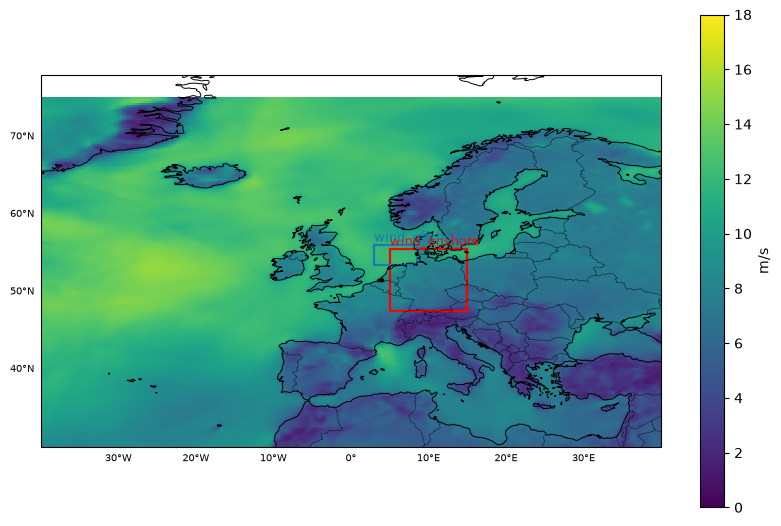

In [3]:
# Map the analysis domain: Jan-2023 mean ws100 shaded, fleet-proxy boxes as rectangles,
# political boundaries from Natural Earth.
ds = era5["2023-01"]
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": PC})
map_ax(ax, "ERA5 domain: Jan-2023 mean ws100 + fleet-proxy boxes")
ds.ws100.mean("time").plot.pcolormesh(
    ax=ax,
    transform=PC,
    cmap="viridis",
    vmin=0,
    vmax=18,
    add_colorbar=True,
    cbar_kwargs={"label": "m/s", "shrink": 0.8},
)
for (name, (la0, la1, lo0, lo1)), col in zip(FLEET_BOXES.items(), ["red", "tab:blue"], strict=True):
    ax.add_patch(
        mpatches.Rectangle(
            (lo0, la0),
            lo1 - lo0,
            la1 - la0,
            fill=False,
            ec=col,
            lw=1.6,
            transform=PC,
        )
    )
    ax.text(lo0, la1 + 0.5, name, color=col, fontsize=9, transform=PC)
plt.show()

*Figure — ERA5 January-2023 mean 100 m wind speed over the analysis domain*
*(ARCO-ERA5, 0.25°, local Zarr cache `data/era5/`). Coastlines and country borders:*
*Natural Earth 50 m. Red/blue rectangles: onshore/offshore fleet-proxy boxes used by the*
*Phase 03 transfer function. Axes are longitude/latitude in degrees.*


### 1.2 The wind resource — general checks

**Left: time-mean speed** — expect maxima over the North Atlantic / North Sea, sharp
orographic reduction over the Alps and Scandinavia. **Right: temporal standard deviation** —
where the wind *varies*; storm tracks show up here, and variability is what drives
ramps and droughts.


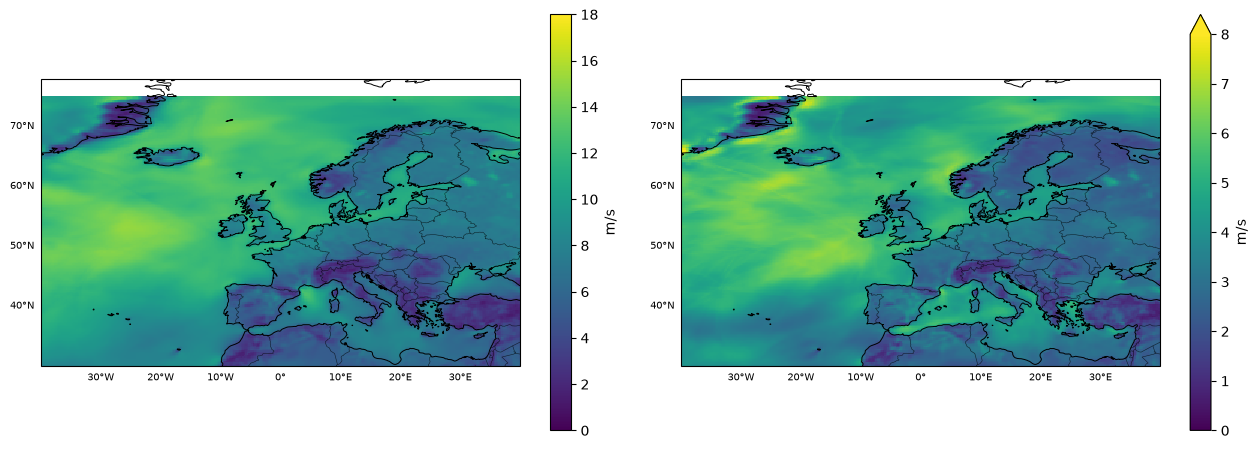

In [4]:
# Wind-resource maps: time-mean ws100 (left) and hourly temporal std dev (right), Jan 2023.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), subplot_kw={"projection": PC})
for ax, (da, ttl, vmax) in zip(
    axes,
    [
        (ds.ws100.mean("time"), "mean ws100, Jan 2023", 18),
        (ds.ws100.std("time"), "std dev of ws100, Jan 2023", 8),
    ],
    strict=True,
):
    map_ax(ax, ttl)
    da.plot.pcolormesh(
        ax=ax,
        transform=PC,
        cmap="viridis",
        vmin=0,
        vmax=vmax,
        add_colorbar=True,
        cbar_kwargs={"label": "m/s", "shrink": 0.8},
    )
fig.tight_layout()
plt.show()

*Figure — left: Jan-2023 mean 100 m wind speed; right: its temporal standard deviation*
*(source: ERA5 via ARCO; `ws100 = hypot(u100, v100)`). Sanity checks: maxima over the*
*Atlantic/North Sea, minima over mountains — the field looks physically right.*


In [5]:
# Statistics for ws100 and surface pressure per window: mean, std, percentiles, NaN fraction.
stats = []
for w, d in era5.items():
    for v in ["ws100", "sp"]:
        a = d[v].values.ravel()
        stats.append(
            {
                "window": w,
                "var": v,
                "mean": a.mean(),
                "std": a.std(),
                "p01": np.percentile(a, 1),
                "p50": np.percentile(a, 50),
                "p99": np.percentile(a, 99),
                "nan_frac": np.isnan(a).mean(),
            }
        )
pl.DataFrame(stats)

window,var,mean,std,p01,p50,p99,nan_frac
str,str,f64,f64,f64,f64,f64,f64
"""2023-01""","""ws100""",9.198788,5.321138,0.785209,8.473738,23.304243,0.0
"""2023-01""","""sp""",98865.632812,5799.618652,68557.765625,100335.890625,103750.960938,0.0
"""2024-11..12""","""ws100""",8.886057,5.28858,0.751936,8.081741,23.301638,0.0
"""2024-11..12""","""sp""",99070.234375,5708.672363,69171.617188,100735.8125,103711.234375,0.0


Per-cell distribution (left) and domain-mean time series (right), both windows overlaid.
Nov–Dec 2024 shows the same right tail but a fatter calm shoulder — consistent with the
dark lulls that window was chosen for.


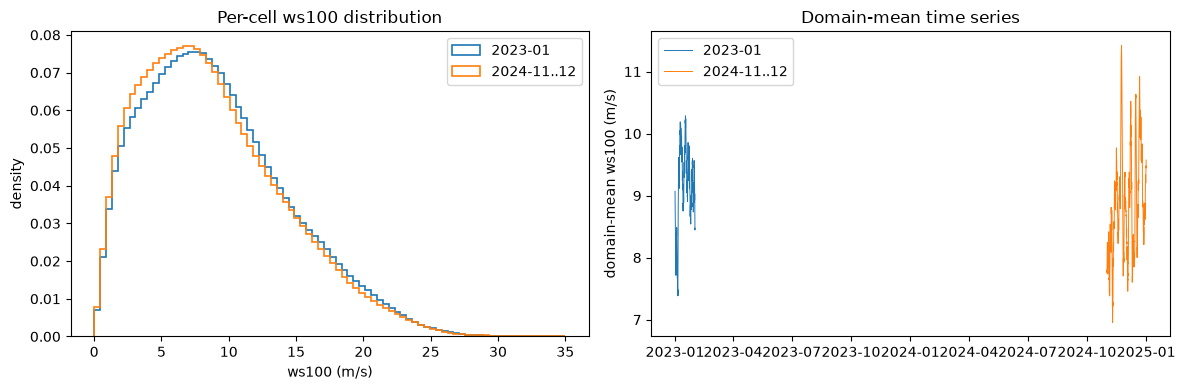

In [6]:
# ws100 distribution (all cells x hours, normalised) and domain-mean time series per window.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for w, d in era5.items():
    axes[0].hist(
        d.ws100.values.ravel(),
        bins=80,
        range=(0, 35),
        histtype="step",
        lw=1.2,
        density=True,
        label=w,
    )
    axes[1].plot(d.time.values, d.ws100.mean(("lat", "lon")).values, lw=0.7, label=w)
axes[0].set(xlabel="ws100 (m/s)", ylabel="density", title="Per-cell ws100 distribution")
axes[0].legend()
axes[1].set(ylabel="domain-mean ws100 (m/s)", title="Domain-mean time series")
axes[1].legend()
fig.tight_layout()
plt.show()

*Figure — ERA5/ARCO data. Left: histogram over every grid cell and hour; right: domain-mean*
*hourly series for Jan 2023 and Nov–Dec 2024. p99 ≈ 21–23 m/s, no NaNs — download is clean.*


### 1.3 Reading a 500 hPa geopotential map — one snapshot first

Before the mean field, the raw variable needs interpreting. **`z500` is the height (in metres)
of the surface where air pressure equals 500 hPa** — roughly the mid-troposphere, ~5.5 km up.
The near-geostrophic flow at that level steers surface weather.

How to read the map:
- **High contours bulging north** = a *ridge* (warm, settled air mass; strong ridges that stall
  are what 'blocking' means physically).
- **Low contours dipping south** = a *trough* (cold, unsettled).
- **Tight contour spacing** = strong flow. Flow runs *along* the contours, counterclockwise
  around lows, clockwise around highs in the Northern Hemisphere.

Below: one instantaneous field (2023-01-01 12 UTC, the same moment as the Phase 02 gate figure).
Look for the ridge over Europe — this is what a Dunkelflaute-promoting circulation looks
like at 500 hPa.


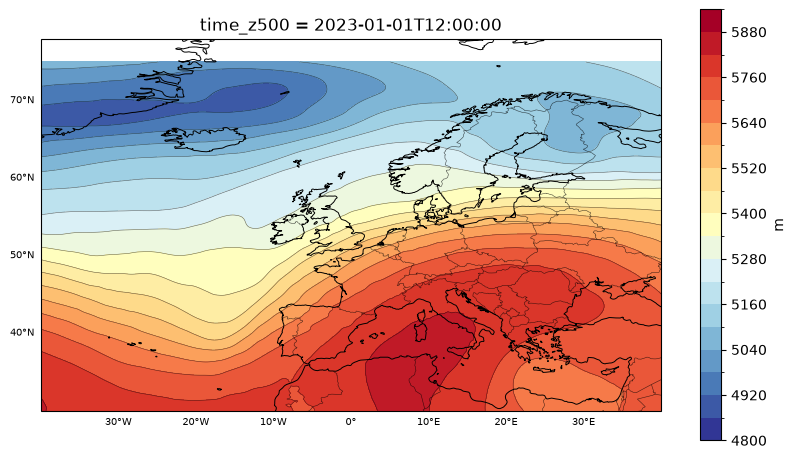

In [7]:
# One instantaneous Z500 field: 2023-01-01 12 UTC. Filled + line contours, 60 m interval.
ds = era5["2023-01"]
fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={"projection": PC})
z = ds.z500.sel(time_z500="2023-01-01T12")
map_ax(ax, "Z500 snapshot, 2023-01-01 12 UTC")
z.plot.contourf(
    ax=ax,
    transform=PC,
    levels=range(4800, 6000, 60),
    cmap="RdYlBu_r",
    add_colorbar=True,
    cbar_kwargs={"label": "m", "shrink": 0.8},
)
z.plot.contour(ax=ax, transform=PC, levels=range(4800, 6000, 60), colors="k", linewidths=0.4, alpha=0.6)
plt.show()

*Figure — ERA5 500 hPa geopotential height, single 6-hourly timestep 2023-01-01 12 UTC.*
*Contour interval 60 m. This is the instantaneous field the Tibaldi–Molteni index operates on.*


**Then the mean.** Time-averaging smooths the moving synoptic features and leaves the
stationary climatological structure — the January ridge and the Nov–Dec pattern differ
visibly. The TM1990 index looks for *reversed meridional gradients* (height increasing
*northward* between 40°N and 80°N) persisting ≥5 days — i.e., a ridge strong enough to
eclipse the usual poleward height decrease. The instantaneous fields above are what it
tests, not this mean.


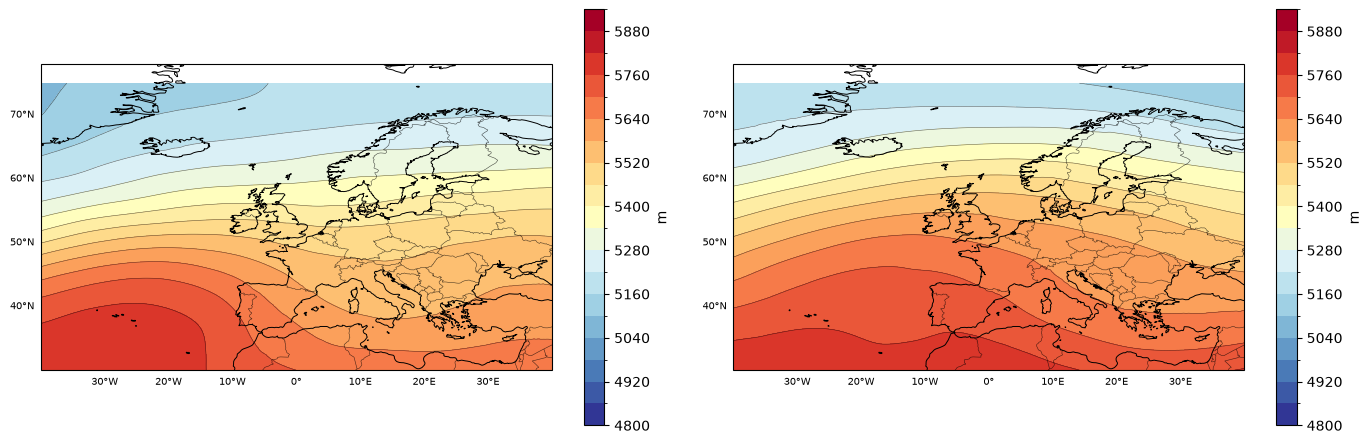

In [8]:
# Mean Z500 per window — stationary climatological structure for comparison.
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), subplot_kw={"projection": PC})
for ax, w in zip(axes, era5, strict=True):
    z = era5[w].z500.mean("time_z500")
    map_ax(ax, f"Mean Z500, {w}")
    z.plot.contourf(
        ax=ax,
        transform=PC,
        levels=range(4800, 6000, 60),
        cmap="RdYlBu_r",
        add_colorbar=True,
        cbar_kwargs={"label": "m", "shrink": 0.8},
    )
    z.plot.contour(ax=ax, transform=PC, levels=range(4800, 6000, 60), colors="k", linewidths=0.4, alpha=0.6)
fig.tight_layout()
plt.show()

*Figure — mean Z500 per cached window (ERA5/ARCO, 60 m contours). Time-mean only;*
*blocking tests run on daily 6-hourly fields.*


### 1.4 Surface pressure

Downloaded for a later purpose: where a climate model's 1000 hPa level would sit below
ground, its near-100 m wind is invalid — `sp` is how we flag that. Check: near 101 kPa
over sea, well below at altitude; no NaNs (see stats table above).


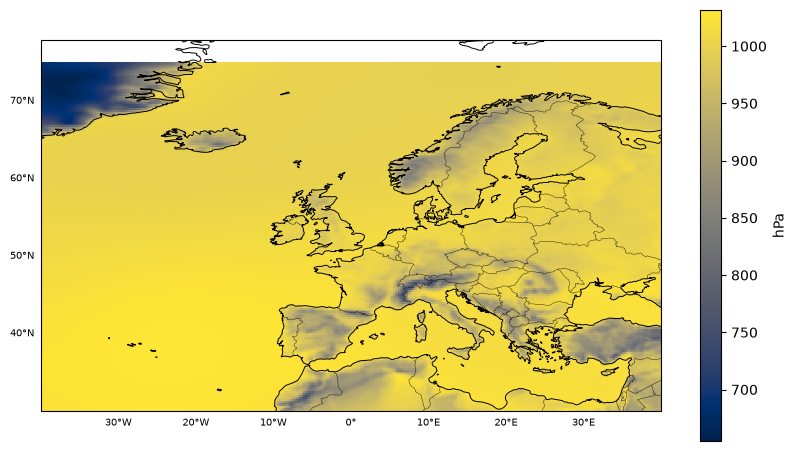

In [9]:
# Mean surface-pressure map (hPa) for Jan 2023.
fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={"projection": PC})
map_ax(ax, "Mean surface pressure, Jan 2023")
(ds.sp.mean("time") / 100).plot.pcolormesh(
    ax=ax,
    transform=PC,
    cmap="cividis",
    add_colorbar=True,
    cbar_kwargs={"label": "hPa", "shrink": 0.8},
)
plt.show()

*Figure — Jan-2023 mean surface pressure (ERA5/ARCO), hPa. Low values over the Alps and*
*Norway mark where a climate-model 1000 hPa level would sit underground.*


## 2. SMARD — where it comes from and what was downloaded

The Bundesnetzagentur's market-data API — actual metered feed-in per TSO zone, the ground
truth the transfer function is validated against. We downloaded **generation and installed
capacity**, hourly, wind onshore/offshore/solar, all four zones, both windows. Capacity is
needed because the metric that matters is *capacity factor* (generation ÷ capacity at that
moment), and the fleet grew over the period. Values are MWh/interval, which at hourly
cadence equals mean MW.

Provenance caveat: generation filter IDs are public; capacity IDs (186/187/188) were
**inferred** by matching Germany-wide yearly totals to known capacities. The step plots
below are the check: roughly ~60 GW onshore, ~9 GW offshore, ~90 GW PV expected by 2024.


In [10]:
# Download SMARD generation + installed capacity for both windows; per-zone inventory
# (row counts, nulls, mean and max MW).
smard = SmardClient(cache_dir=cfg["smard"]["cache_dir"])
frames = {}
for w, (s, e) in WINDOWS.items():
    s, e = datetime.fromisoformat(s), datetime.fromisoformat(e)
    frames[w] = {
        "gen": smard.load_generation(s, e),
        "cap": smard.load_installed_capacity(s, e),
        "cf": None,  # filled below
    }
    frames[w]["cf"] = capacity_factor(frames[w]["gen"], frames[w]["cap"])

inv = []
for w, f in frames.items():
    for kind in ("gen", "cap"):
        g = (
            f[kind]
            .group_by("zone", "variable")
            .agg(
                n=pl.len(),
                nulls=pl.col("value_mw").null_count(),
                mean_mw=pl.col("value_mw").mean(),
                max_mw=pl.col("value_mw").max(),
            )
        )
        inv += [dict(window=w, kind=kind, **r) for r in g.to_dicts()]
pl.DataFrame(inv).sort("window", "kind", "zone", "variable")

window,kind,zone,variable,n,nulls,mean_mw,max_mw
str,str,str,str,i64,i64,f64,f64
"""2023-01""","""cap""","""50Hertz""","""solar""",744,0,16250.0,16250.0
"""2023-01""","""cap""","""50Hertz""","""wind_offshore""",744,0,1093.0,1093.0
"""2023-01""","""cap""","""50Hertz""","""wind_onshore""",744,0,20756.0,20756.0
"""2023-01""","""cap""","""Amprion""","""solar""",744,0,14475.0,14475.0
"""2023-01""","""cap""","""Amprion""","""wind_offshore""",744,0,0.0,0.0
…,…,…,…,…,…,…,…
"""2024-11..12""","""gen""","""TenneT""","""wind_offshore""",1464,0,2505.301742,6066.5
"""2024-11..12""","""gen""","""TenneT""","""wind_onshore""",1464,0,7030.605874,19195.0
"""2024-11..12""","""gen""","""TransnetBW""","""solar""",1464,0,323.635587,3208.5


### 2.1 Installed capacity — the denominator check


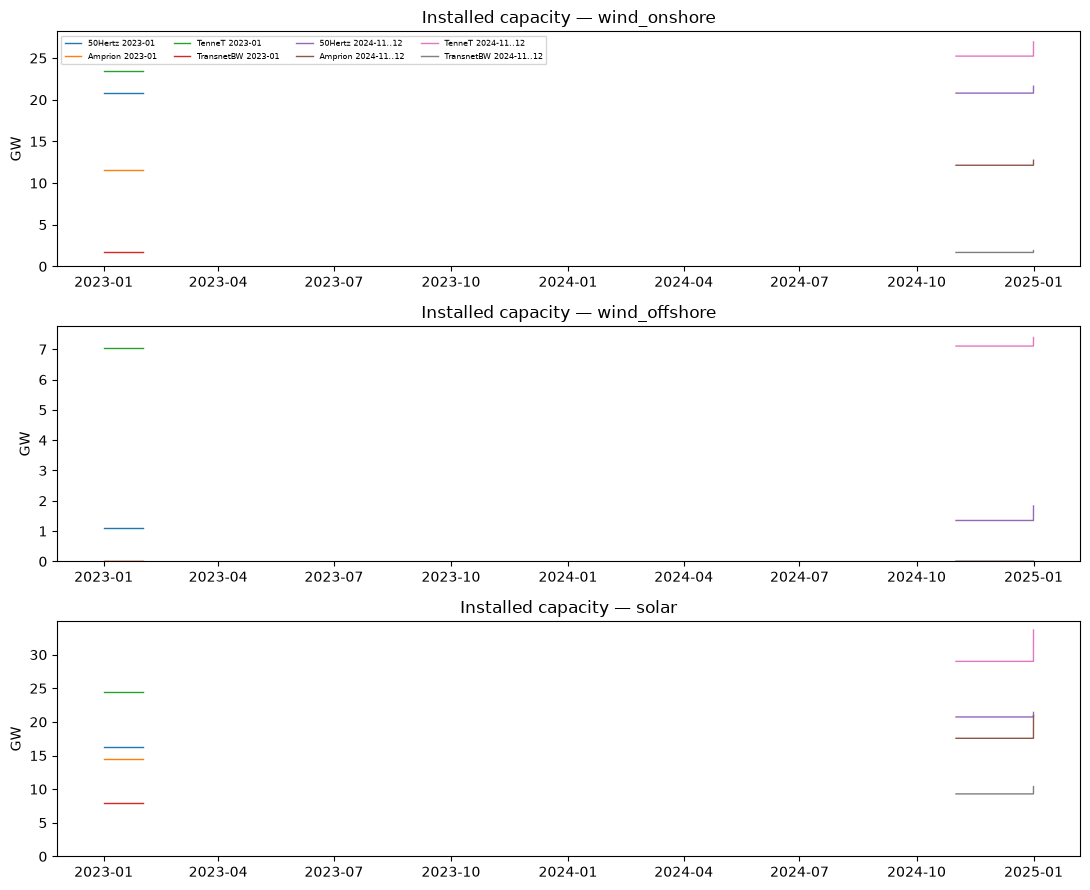

In [11]:
# Installed-capacity step plots per technology; each line is one zone x window.
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=False)
for ax, var in zip(axes, ["wind_onshore", "wind_offshore", "solar"], strict=True):
    for w, f in frames.items():
        d = f["cap"].filter(pl.col("variable") == var).to_pandas()
        for z, g in d.groupby("zone"):
            ax.plot(g.time, g.value_mw / 1000, lw=1.0, label=f"{z} {w}" if var == "wind_onshore" else None)
        ax.set(ylabel="GW", title=f"Installed capacity — {var}")
    ax.set_ylim(0)
axes[0].legend(fontsize=6, ncol=4)
fig.tight_layout()
plt.show()

*Figure — installed capacity by TSO zone and technology (SMARD API, filter IDs 186/187/188,*
*inferred). Sanity check: Germany totals should read ≈60 GW onshore, ≈9 GW offshore,*
*≈90 GW PV in late 2024 — and they do (50Hertz ≈25 GW onshore alone is eastern Germany).*


### 2.2 Spatial view — installed capacity by zone

SMARD reports **zonal aggregates**, not plant coordinates, so the honest spatial figure
is bubbles at (approximate) zone centroids sized by installed capacity — one panel per
technology. Offshore bubbles are placed over the sea each zone actually feeds
(50Hertz → Baltic, TenneT → North Sea). True plant-level spatial resolution is the
planned MaStR addition.


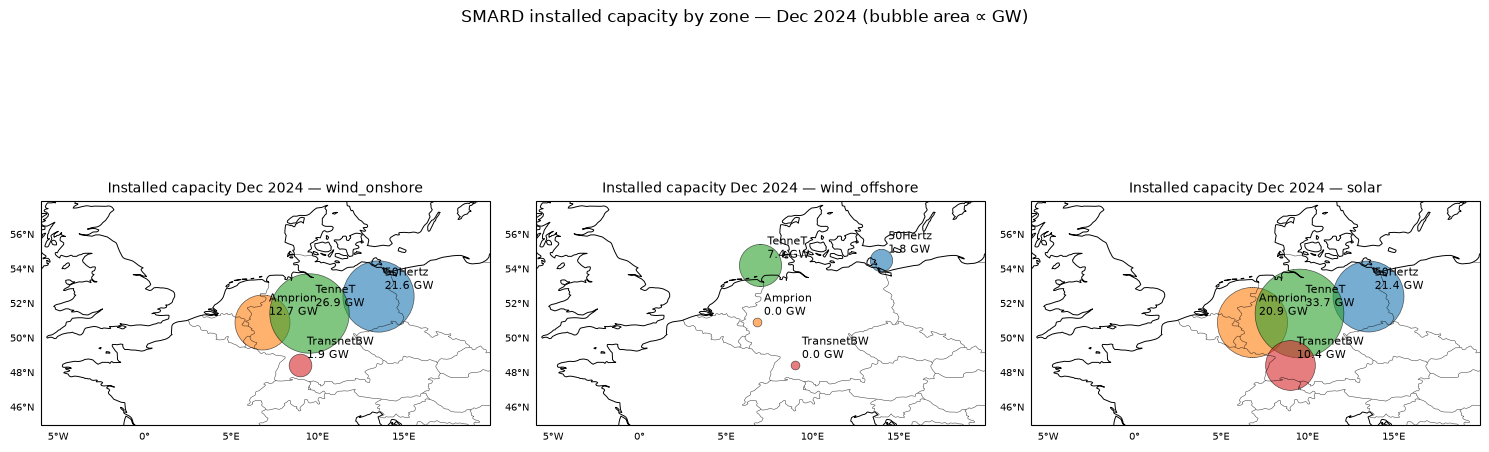

In [12]:
# Zonal installed-capacity map: bubble at each zone's approximate centroid, sized by GW,
# separately per technology. Offshore bubbles at sea (50Hertz=Baltic, TenneT=North Sea).
CENTROIDS = {  # approximate TSO-zone centroids (lat, lon), display only
    "50Hertz": (52.5, 13.5),
    "TenneT": (51.5, 9.5),
    "Amprion": (51.0, 6.8),
    "TransnetBW": (48.5, 9.0),
}
OFFSHORE_SEA = {"50Hertz": (54.6, 14.0), "TenneT": (54.3, 7.0)}  # Baltic / North Sea

fig, axes = plt.subplots(1, 3, figsize=(15, 6), subplot_kw={"projection": PC})
for ax, var in zip(axes, ["wind_onshore", "wind_offshore", "solar"], strict=True):
    map_ax(ax, f"Installed capacity Dec 2024 — {var}")
    cap = frames["2024-11..12"]["cap"].filter(
        pl.col("variable") == var, pl.col("time") == pl.col("time").max()
    )
    for r in cap.iter_rows(named=True):
        z, v = r["zone"], r["value_mw"] / 1000
        lat, lon = OFFSHORE_SEA.get(z, CENTROIDS[z]) if var == "wind_offshore" else CENTROIDS[z]
        ax.scatter(lon, lat, s=40 + v * 120, transform=PC, alpha=0.6, edgecolors="k", lw=0.5)
        ax.text(lon + 0.4, lat + 0.4, f"{z}\n{v:.1f} GW", fontsize=8, transform=PC)
    ax.set_xlim(-6, 20)
    ax.set_ylim(45, 58)
fig.suptitle("SMARD installed capacity by zone — Dec 2024 (bubble area ∝ GW)")
fig.tight_layout()
plt.show()

*Figure — SMARD zonal installed capacity, Dec 2024, as centroid bubbles (approximate*
*centroids; offshore at the Baltic/North-Sea feed-in areas). Solar concentrates in*
*Amprion/TransnetBW (south/west); offshore only exists in 50Hertz and TenneT — for the*
*southern zones it is a structural zero.*


### 2.3 Observed generation — the signal being modelled

**Germany-total hourly wind + solar generation** in each window. This is the shape of the
problem: deep multi-day wind holes (the dark lulls) embedded in highly variable output,
and solar contributing almost nothing in winter. The near-zero stretches are the
Dunkelflaute events this project studies.


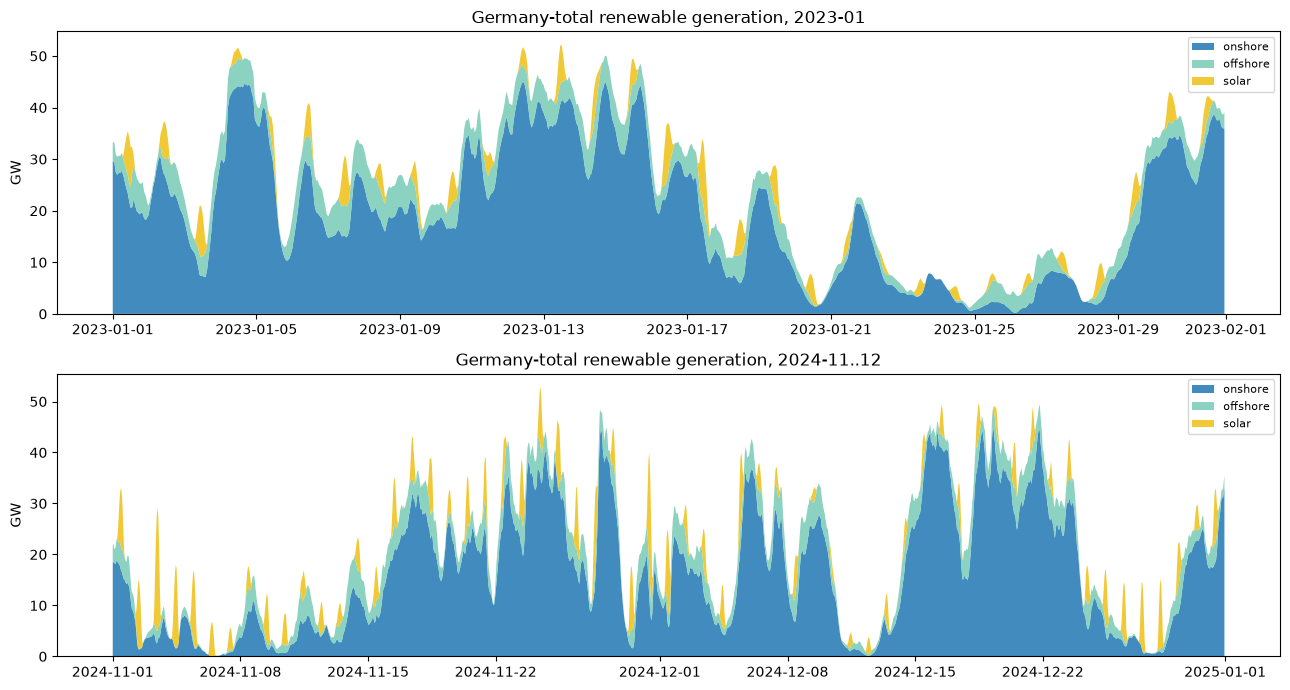

In [13]:
# Germany-total hourly renewable generation, stacked by technology, per window.
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=False)
for ax, (w, f) in zip(axes, frames.items(), strict=True):
    nat = (
        f["gen"]
        .group_by("time", "variable")
        .agg(pl.col("value_mw").sum())
        .to_pandas()
        .pivot(index="time", columns="variable", values="value_mw")
        .fillna(0)
        / 1000
    )
    ax.stackplot(
        nat.index,
        nat["wind_onshore"],
        nat["wind_offshore"],
        nat["solar"],
        labels=["onshore", "offshore", "solar"],
        colors=["#2c7fb8", "#7fcdbb", "#f0c420"],
        alpha=0.9,
    )
    ax.set(ylabel="GW", title=f"Germany-total renewable generation, {w}")
    ax.legend(loc="upper right", fontsize=8)
    ax.set_ylim(0)
fig.tight_layout()
plt.show()

*Figure — Germany-total hourly renewable generation (SMARD), stacked onshore/offshore/solar.*
*Near-zero stretches (Jan 21–28 2023; Nov 5–8, Dec 10–14, Dec 24–27 2024) are the dark lulls.*


### 2.4 Capacity factors per zone

The distribution of CF per zone and window — **this is what the transfer function must**
**reproduce.** Offshore sits higher and tighter than onshore; Nov–Dec 2024 shifts down
visibly (the lulls); solar ~2% winter CF. Amprion/TransnetBW offshore are structurally zero.


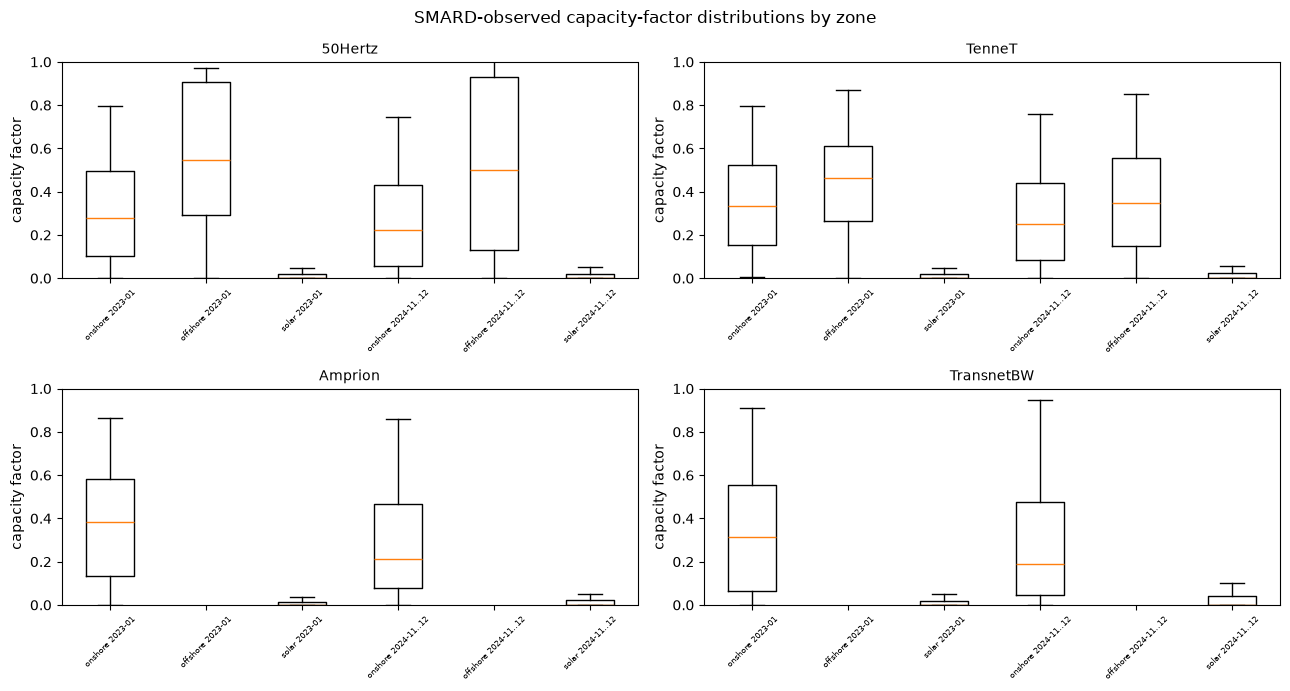

In [14]:
# Per-zone CF boxplots: both windows x all three technologies.
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
zones = ["50Hertz", "TenneT", "Amprion", "TransnetBW"]
for ax, zone in zip(axes.ravel(), zones, strict=True):
    data, labels = [], []
    for w, f in frames.items():
        for var in ["wind_onshore", "wind_offshore", "solar"]:
            s = (
                f["cf"]
                .filter(pl.col("zone") == zone, pl.col("variable") == var)["capacity_factor"]
                .drop_nans()
            )
            data.append(s.to_numpy())
            labels.append(f"{var.replace('wind_', '')} {w}")
    ax.boxplot(data, tick_labels=labels, showfliers=False)
    ax.set_ylim(0, 1)
    ax.set_title(zone, fontsize=10)
    ax.tick_params(axis="x", labelsize=6, rotation=45)
    ax.set_ylabel("capacity factor")
fig.suptitle("SMARD-observed capacity-factor distributions by zone")
fig.tight_layout()
plt.show()

*Figure — SMARD-observed capacity-factor distributions per zone (box = IQR, whiskers,*
*outliers hidden), both windows. This is the target distribution the transfer model must*
*reproduce.*


**Gaps and quirks worth knowing:**
- Occasional `null` hours in the feed (see `nulls` column above) — real gaps, kept as null not zero.
- Generation is MWh/interval; hourly equals mean MW. Quarter-hourly is available but not downloaded.
- Solar stays observed-only: no radiation variable is downloaded, so it has no transfer function.



## 3. Coverage summary — downloaded vs. planned

| | on disk | planned (later phases) |
|---|---|---|
| ERA5 | ws100/u100/v100/sp hourly + z500 6h, Jan 2023 + Nov–Dec 2024, 30–75°N / 40°W–40°E | extend windows for the 30-yr blocking climatology |
| SMARD | hourly gen + capacity, 4 zones, Jan 2023 + Nov–Dec 2024 | quarter-hourly if ramp analysis needs it |
| EERIE | *nothing yet* | 3-D u/v/z pressure levels (6h), 2-D sp/gusts; hist-1950 + ssp245, Phase 06 gated on the ERA5 pipeline |
| MaStR | *nothing* | turbine locations for capacity-weighted aggregation (biggest known transfer bias) |

Reading order for the science: ERA5 + SMARD are the calibration pair. EERIE only enters after
the same diagnostics reproduce ERA5's known answers — that is the evaluative logic of the project.
